In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import scipy as sp
from scipy import stats

import nibabel as nib

from sklearn.neighbors import KDTree
from sklearn.metrics import pairwise_distances

import glob
import pickle

# 0.Preprocessing

In [2]:
## atlas info
atlas_info = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/rawdata/lausanne_scale60_atlas_info.csv", index_col=0)

In [3]:
## sEEG
# eeg = pd.read_csv("../rawdata/probability.csv", skiprows=4, index_col=0)
# eeg = eeg.loc[atlas_info["alias1"], ].loc[:, atlas_info["alias1"]]
# eeg_left = eeg.iloc[64:128, 64:128]
# eeg_left.to_csv("../res/01.gene_selection/eeg_left.csv")

In [4]:
## AHBA
expr_files = glob.glob("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/processed/08.AHBA_processing/res/lausanne_exprs*.csv")
expr_files.sort()
for f in expr_files:
    prefix = f.split("/")[-1].split(".")[0]
    if prefix.find("counts") >= 0:
        continue

    expr = pd.read_csv(f, index_col=0)
    expr.index = atlas_info["alias1"].values

    expr_left = expr.iloc[64:128, :]
    num_na = expr_left.isna().sum().sum()
    print(prefix, num_na)

    if num_na == 0:
        expr_left.to_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/expr_left_kwx.csv")
    #break

lausanne_exprs 0
lausanne_exprs_10021 62536
lausanne_exprs_12876 140706
lausanne_exprs_14380 46956
lausanne_exprs_15496 46956
lausanne_exprs_15697 15634
lausanne_exprs_9861 46902


# 1.Gene selection

In [5]:
## only left hemi were considered
# eeg = pd.read_csv("../res/01.gene_selection/eeg_left.csv", index_col=0)
expr = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/expr_left_kwx.csv", index_col=0)
wm_roi_map = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/processed/06.active_map/res/roi_map/working-memory_roi_kwx.csv", index_col=0, header=None).iloc[64:128, :]
expr.shape, wm_roi_map.shape, np.all(wm_roi_map.index == expr.index)

((64, 15634), (64, 1), np.True_)

In [7]:
def calc_correlation(y, x, method):
    if method == "spearman":
        tmp_y = y.rank().values
        tmp_x = x.rank(axis=0).values
    else:
        tmp_y = y.values
        tmp_x = x.values
    return np.array([ np.corrcoef(tmp_x[:, i], tmp_y)[0, 1] for i in range(tmp_x.shape[1])])

pr_mat, sp_mat = {}, {}
roi_val = wm_roi_map.loc[:, 1]
use_region = roi_val.index[~roi_val.isna()]
use_region = use_region[~use_region.isin(["rh.frontalpole_1"])]

for region in use_region:
    if len(use_region) < 5:
        pr_mat[region] = np.zeros(expr.shape[1])
        sp_mat[region] = np.zeros(expr.shape[1])
    else:
        expr_use = expr.loc[use_region, :]
        roi_use = roi_val.loc[use_region]
        pr_mat[region] = calc_correlation(roi_use, expr_use, method="pearson")
        sp_mat[region] = calc_correlation(roi_use, expr_use, method="spearman")
print(region) 
print(pr_mat)
print(sp_mat)

Left-Amygdala
{'lh.lateralorbitofrontal_1': array([-0.31825763, -0.05812416,  0.07365942, ...,  0.29096866,
        0.07302475, -0.28872509]), 'lh.lateralorbitofrontal_2': array([-0.31825763, -0.05812416,  0.07365942, ...,  0.29096866,
        0.07302475, -0.28872509]), 'lh.parsorbitalis_1': array([-0.31825763, -0.05812416,  0.07365942, ...,  0.29096866,
        0.07302475, -0.28872509]), 'lh.frontalpole_1': array([-0.31825763, -0.05812416,  0.07365942, ...,  0.29096866,
        0.07302475, -0.28872509]), 'lh.medialorbitofrontal_1': array([-0.31825763, -0.05812416,  0.07365942, ...,  0.29096866,
        0.07302475, -0.28872509]), 'lh.parstriangularis_1': array([-0.31825763, -0.05812416,  0.07365942, ...,  0.29096866,
        0.07302475, -0.28872509]), 'lh.parsopercularis_1': array([-0.31825763, -0.05812416,  0.07365942, ...,  0.29096866,
        0.07302475, -0.28872509]), 'lh.rostralmiddlefrontal_1': array([-0.31825763, -0.05812416,  0.07365942, ...,  0.29096866,
        0.07302475, -0

In [8]:
pr_df = pd.DataFrame(pr_mat).T
pr_df.columns = expr.columns
pr_df.to_pickle("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/wm_pr_df_activate_kwx.pkl")

sp_df = pd.DataFrame(sp_mat).T
sp_df.columns = expr.columns
sp_df.to_pickle("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/wm_sp_df_activate_kwx.pkl")

In [14]:
## only left hemi were considered
eeg = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/methods_from_dzc/01.HumanEEGNeurosynth_WM_kwx_pAgF/res/01.gene_selection/eeg_left_kwx.csv", index_col=0)
# expr = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/methods_from_dzc/01.HumanEEGNeurosynth_WM_kwx_pAgF/res/01.gene_selection/expr_left_kwx.csv", index_col=0)
wm_roi_map = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/methods_from_dzc/01.HumanEEGNeurosynth_WM_kwx_pAgF/processed/03.active_map/res/roi_map/working-memory_roi_kwx.csv", index_col=0, header=None).iloc[64:128, :]
eeg.shape, wm_roi_map.shape, np.all(eeg.index == wm_roi_map.index)

((64, 64), (64, 1), np.True_)

In [21]:
# 初始化结果容器 
result_vector = np.zeros(len(eeg.index))   # 用于存储点乘结果
 
# 遍历每个脑区 
for i, region in enumerate(eeg.index): 
    # 获取当前脑区的EEG数据
    eeg_val = eeg.loc[region,  :]
    
    # 找出非空值对应的脑区（排除特定区域）
    valid_regions = eeg_val.index[~eeg_val.isna()] 
    valid_regions = valid_regions[~valid_regions.isin(["rh.frontalpole_1"])] 
    
    # 计算点乘（仅使用有效数据）
    if not valid_regions.empty: 
        # 提取有效数据
        eeg_valid = eeg_val.loc[valid_regions] 
        wm_valid = wm_roi_map.loc[valid_regions, 1]  # 注意：wm_roi_map只有一列
        
        # 计算点乘（对应元素相乘后求和）
        result_vector[i] = (eeg_valid * wm_valid).sum()
    
    print(f"处理进度: {i+1}/{len(eeg.index)}  - {region}")
 
# 转换为DataFrame 
result_df = pd.DataFrame(result_vector, index=eeg.index,  columns=['Dot_Product'])
 
print("\n点乘结果:")
print(result_df)
result_df.to_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/methods_from_dzc/01.HumanEEGNeurosynth_WM_kwx_pAgF/res/01.gene_selection/weighted_connect_scores_kwx.csv", header=False)

处理进度: 1/64  - lh.lateralorbitofrontal_1
处理进度: 2/64  - lh.lateralorbitofrontal_2
处理进度: 3/64  - lh.parsorbitalis_1
处理进度: 4/64  - lh.frontalpole_1
处理进度: 5/64  - lh.medialorbitofrontal_1
处理进度: 6/64  - lh.parstriangularis_1
处理进度: 7/64  - lh.parsopercularis_1
处理进度: 8/64  - lh.rostralmiddlefrontal_1
处理进度: 9/64  - lh.rostralmiddlefrontal_2
处理进度: 10/64  - lh.rostralmiddlefrontal_3
处理进度: 11/64  - lh.superiorfrontal_1
处理进度: 12/64  - lh.superiorfrontal_2
处理进度: 13/64  - lh.superiorfrontal_3
处理进度: 14/64  - lh.superiorfrontal_4
处理进度: 15/64  - lh.caudalmiddlefrontal_1
处理进度: 16/64  - lh.precentral_1
处理进度: 17/64  - lh.precentral_2
处理进度: 18/64  - lh.precentral_3
处理进度: 19/64  - lh.precentral_4
处理进度: 20/64  - lh.paracentral_1
处理进度: 21/64  - lh.rostralanteriorcingulate_1
处理进度: 22/64  - lh.caudalanteriorcingulate_1
处理进度: 23/64  - lh.posteriorcingulate_1
处理进度: 24/64  - lh.isthmuscingulate_1
处理进度: 25/64  - lh.postcentral_1
处理进度: 26/64  - lh.postcentral_2
处理进度: 27/64  - lh.postcentral_3
处理进度: 28/64  - lh.supram

## 1.1 raw coefficents

In [10]:
wm_roi_map = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/processed/06.active_map/res/roi_map/working-memory_roi.zscore_kwx.csv", index_col=0, header=None).iloc[64:128, :]
wm_roi_map[wm_roi_map[1]<0] = 0

In [11]:
pr_df = pd.read_pickle("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/wm_pr_df_activate_kwx.pkl")
sp_df = pd.read_pickle("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/wm_sp_df_activate_kwx.pkl")

gene_score_pr = (pr_df.T * wm_roi_map[1]).sum(axis=1).sort_values(ascending=False)
gene_score_sp = (sp_df.T * wm_roi_map[1]).sum(axis=1).sort_values(ascending=False)

gene_score_pr.to_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/gene_score_pr_activate_kwx.csv", header=None)
gene_score_sp.to_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/gene_score_sp_activate_kwx.csv", header=None)
gene_score_pr.shape, gene_score_sp.shape

((15634,), (15634,))

In [12]:
gene_score_pr = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/gene_score_pr_activate_kwx.csv", header=None, index_col=0)
gene_score_sp = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/gene_score_sp_activate_kwx.csv", header=None, index_col=0)

In [13]:
## 两种结果的相关性 
a = gene_score_pr[1].values
b = gene_score_sp.loc[gene_score_pr.index, 1]
stats.pearsonr(a, b), stats.spearmanr(a, b)

(PearsonRResult(statistic=np.float64(0.9578438605630963), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.9566817388531883), pvalue=np.float64(0.0)))

In [14]:
(gene_score_pr == 0).sum(), (gene_score_sp == 0).sum()

(1    0
 dtype: int64,
 1    1
 dtype: int64)

In [15]:
topk_list = np.linspace(0, 1, 101)[1:]
jac_idx_posi = []
jac_idx_nega = []
for t in topk_list:
    n = int(gene_score_pr.loc[gene_score_pr[1] > 0, ].shape[0] * t)

    pr_set = set(gene_score_pr.loc[gene_score_pr[1] > 0, ].index.values[:n])
    sp_set = set(gene_score_sp.loc[gene_score_sp[1] > 0, ].index.values[:n])
    jac_idx_posi.append( len(pr_set & sp_set) / max(len(pr_set|sp_set), 1) )

    n = int(gene_score_pr.loc[gene_score_pr[1] < 0, ].shape[0] * t)
    pr_set = set(gene_score_pr.loc[gene_score_pr[1] < 0, ].index.values[-n:])
    sp_set = set(gene_score_sp.loc[gene_score_sp[1] < 0, ].index.values[-n:])
    jac_idx_nega.append( len(pr_set & sp_set) / max(len(pr_set|sp_set), 1) )

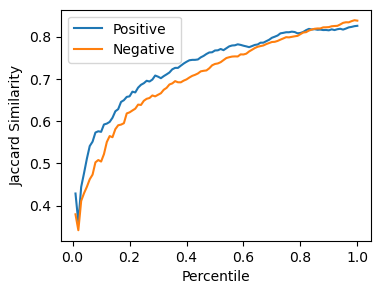

In [16]:
plt.figure(figsize=(4, 3))
plt.plot(topk_list, jac_idx_posi, label="Positive")
plt.plot(topk_list, jac_idx_nega, label="Negative")
plt.xlabel("Percentile")
plt.ylabel("Jaccard Similarity")
plt.legend()
plt.savefig('/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/plot/JaccardSimilarity_activate_kwx.png', bbox_inches='tight')
plt.show()

In [17]:
topk_list = np.linspace(0, 1, 101)
## positive
jac_idx_posi = []
for t1 in topk_list[1:]:
    tmp = []

    n1 = int(gene_score_pr.loc[gene_score_pr[1] > 0, ].shape[0] * t1)
    pr_set = set(gene_score_pr.loc[gene_score_pr[1] > 0, ].index.values[:n1])
    for t2 in topk_list[1:]:
        n2 = int(gene_score_sp.shape[0] * t2)
        sp_set = set(gene_score_sp.index.values[:n2])

        tmp.append( len(pr_set & sp_set) / max(len(pr_set|sp_set), 1) )
    jac_idx_posi.append(tmp)

## negative

jac_idx_nega = []
for t1 in topk_list[1:]:
    tmp = []

    n1 = int(gene_score_pr.loc[gene_score_pr[1] < 0, ].shape[0] * t1)
    pr_set = set(gene_score_pr.loc[gene_score_pr[1] < 0, ].index.values[-n1:])
    for t2 in topk_list[1:]:
        n2 = int(gene_score_sp.loc[gene_score_sp[1] < 0, ].shape[0] * t2)
        sp_set = set(gene_score_sp.loc[gene_score_sp[1] < 0, ].index.values[-n2:])

        tmp.append( len(pr_set & sp_set) / max(len(pr_set|sp_set), 1) )
    jac_idx_nega.append(tmp)

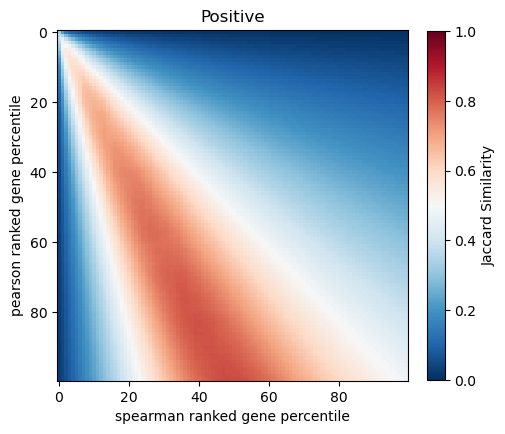

In [18]:
plt.figure(figsize=(5, 5))
plt.imshow(jac_idx_posi, vmin=0, vmax=1, cmap='RdBu_r')
plt.xlabel("spearman ranked gene percentile")
plt.ylabel("pearson ranked gene percentile")
plt.colorbar(fraction=0.045, label="Jaccard Similarity")
plt.title("Positive")
plt.savefig("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/plot/Positive_activate_kwx.png", bbox_inches='tight')
plt.show()

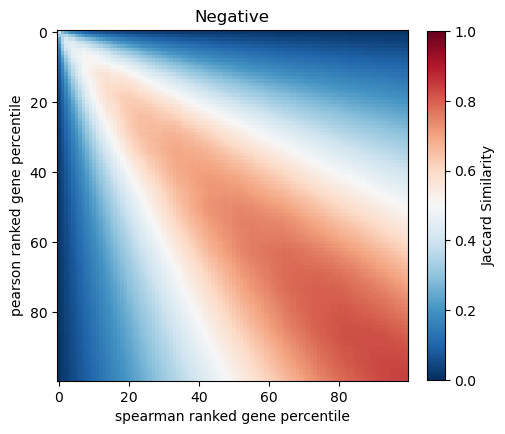

In [19]:
plt.figure(figsize=(5, 5))
plt.imshow(jac_idx_nega, vmin=0, vmax=1, cmap='RdBu_r')
plt.xlabel("spearman ranked gene percentile")
plt.ylabel("pearson ranked gene percentile")
plt.colorbar(fraction=0.045, label="Jaccard Similarity")
plt.title("Negative")
plt.savefig('/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/plot/Negative_activate_kwx.png', bbox_inches='tight')
plt.show()

## 1.2 abs coefficents

* 20230712, 效果可能更优

In [20]:
wm_roi_map = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/processed/06.active_map/res/roi_map/working-memory_roi_kwx.csv", index_col=0, header=None).iloc[64:128, :]
wm_roi_map[wm_roi_map[1]<0] = 0

In [21]:
from sklearn.decomposition import NMF
from sklearn.decomposition import PCA

In [22]:
pca_obj = PCA(n_components=1)

pr_df = pd.read_pickle("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/wm_pr_df_activate_kwx.pkl")
sp_df = pd.read_pickle("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/wm_sp_df_activate_kwx.pkl")

gene_score_pr = (np.abs(pr_df.T) * wm_roi_map[1]) / wm_roi_map[1].values.sum()
gene_score_sp = (np.abs(sp_df.T) * wm_roi_map[1]) / wm_roi_map[1].values.sum()


nmf_obj = NMF(n_components=1)
gene_score_pr = pd.DataFrame( nmf_obj.fit_transform(gene_score_pr.values), index=gene_score_pr.index).sort_values(by=[0], ascending=False)
gene_score_sp = pd.DataFrame( nmf_obj.fit_transform(gene_score_sp.values), index=gene_score_sp.index).sort_values(by=[0], ascending=False)


gene_score_pr.to_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/gene_score_pr_activate.abs_kwx.csv", header=None)
gene_score_sp.to_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/gene_score_sp_activate.abs_kwx.csv", header=None)
gene_score_pr.shape, gene_score_sp.shape

((15634, 1), (15634, 1))

In [23]:
(gene_score_pr.values>0).sum(), (gene_score_pr.values<0).sum(), (gene_score_pr.values==0).sum()

(np.int64(15634), np.int64(0), np.int64(0))

In [24]:
(gene_score_sp.values>0).sum(), (gene_score_sp.values<0).sum(), (gene_score_sp.values==0).sum()

(np.int64(15633), np.int64(0), np.int64(1))

In [25]:
gene_score_pr = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/gene_score_pr_activate.abs_kwx.csv", header=None, index_col=0)
gene_score_sp = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/gene_score_sp_activate.abs_kwx.csv", header=None, index_col=0)

In [26]:
## 两种结果的相关性 
a = gene_score_pr[1].values
b = gene_score_sp.loc[gene_score_pr.index, 1]
stats.pearsonr(a, b), stats.spearmanr(a, b)

(PearsonRResult(statistic=np.float64(0.885005656495326), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.8612114550424923), pvalue=np.float64(0.0)))

In [27]:
topk_list = np.linspace(0, 1, 101)[1:]
jac_idx = []
for t in topk_list:
    n = int(gene_score_pr.shape[0] * t)

    pr_set = set(gene_score_pr.index.values[:n])
    sp_set = set(gene_score_sp.index.values[:n])
    jac_idx.append( len(pr_set & sp_set) / max(len(pr_set|sp_set), 1) )

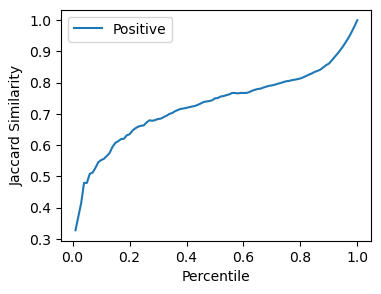

In [28]:
plt.figure(figsize=(4, 3))
plt.plot(topk_list, jac_idx, label="Positive")
plt.xlabel("Percentile")
plt.ylabel("Jaccard Similarity")
plt.legend()
plt.show()

In [29]:
topk_list = np.linspace(0, 1, 101)
## positive
jac_idx_posi = []
for t1 in topk_list[1:]:
    tmp = []

    n1 = int(gene_score_pr.loc[gene_score_pr[1] > 0, ].shape[0] * t1)
    pr_set = set(gene_score_pr.loc[gene_score_pr[1] > 0, ].index.values[:n1])
    for t2 in topk_list[1:]:
        n2 = int(gene_score_sp.shape[0] * t2)
        sp_set = set(gene_score_sp.index.values[:n2])

        tmp.append( len(pr_set & sp_set) / max(len(pr_set|sp_set), 1) )
    jac_idx_posi.append(tmp)

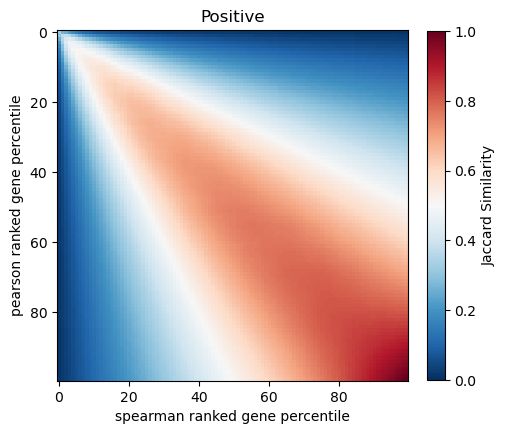

In [30]:
plt.figure(figsize=(5, 5))
plt.imshow(jac_idx_posi, vmin=0, vmax=1, cmap='RdBu_r')
plt.xlabel("spearman ranked gene percentile")
plt.ylabel("pearson ranked gene percentile")
plt.colorbar(fraction=0.045, label="Jaccard Similarity")
plt.title("Positive")
#plt.savefig('tjn.png', bbox_inches='tight')
plt.show()

## 1.3 left-hemi brain expression pattern

In [31]:
from sklearn.decomposition import PCA
from brainsmash.mapgen.stats import spearmanr as bs_spearmanr
from brainsmash.mapgen.stats import pearsonr as bs_pearsonr

import nibabel as nib
from nilearn import plotting

from sklearn.linear_model import TheilSenRegressor

In [32]:
gene_score = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/gene_score_pr_activate.abs_kwx.csv", header=None, index_col=0)
expr = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/expr_left_kwx.csv", index_col=0)

n = int(gene_score.shape[0] * 0.1)
top10_genes = gene_score.index[:n]
top10_genes_expr = expr.loc[:, top10_genes]
top10_genes_expr.to_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/expr_left_top10_activate_kwx.csv")
top10_scores = gene_score.loc[top10_genes, 1]
weighted_region_scores = top10_genes_expr.dot(top10_scores)
weighted_region_scores.to_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/weighted_region_scores_activate_kwx.csv", header=False)

In [1]:
import os
import pandas as pd

# ==============================
# 1. 路径设置
# ==============================
base_dir = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection"

gene_score_path = os.path.join(base_dir, "gene_score_pr_activate.abs_kwx.csv")
expr_path = os.path.join(base_dir, "expr_left_kwx.csv")

# ==============================
# 2. 读取数据
# ==============================
gene_score = pd.read_csv(gene_score_path, header=None, index_col=0)
expr = pd.read_csv(expr_path, index_col=0)

# ==============================
# 3. 定义需要提取的分位区间
# ==============================
percent_ranges = [
    (0.1, 0.2),
    (0.2, 0.3),
    (0.3, 0.4),
    (0.4, 0.5),
    (0.5, 0.6),
    (0.6, 0.7),
    (0.7, 0.8),
    (0.8, 0.9),
    (0.9, 1.0),
]

total_genes = gene_score.shape[0]

# ==============================
# 4. 循环提取每个区间的基因并输出文件
# ==============================
for start_p, end_p in percent_ranges:
    start_idx = int(total_genes * start_p)
    end_idx = int(total_genes * end_p)

    # 和你原始逻辑一致：按排序后的 index 直接切片
    gene_subset = gene_score.index[start_idx:end_idx]

    # 提取表达矩阵
    gene_subset_expr = expr.loc[:, gene_subset]

    # 和你原始逻辑一致：直接取第1列分数
    subset_scores = gene_score.loc[gene_subset, 1]

    # 计算 weighted region scores
    weighted_region_scores = gene_subset_expr.dot(subset_scores)

    # 百分比标签
    start_label = int(start_p * 100)
    end_label = int(end_p * 100)

    # 输出文件名
    expr_out = os.path.join(
        base_dir,
        f"expr_left_top{start_label}_{end_label}_activate_kwx.csv"
    )
    score_out = os.path.join(
        base_dir,
        f"weighted_region_scores_top{start_label}_{end_label}_activate_kwx.csv"
    )

    # 保存
    gene_subset_expr.to_csv(expr_out)
    weighted_region_scores.to_csv(score_out, header=False)

    print(f"Saved: {expr_out}")
    print(f"Saved: {score_out}")

Saved: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/expr_left_top10_20_activate_kwx.csv
Saved: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/weighted_region_scores_top10_20_activate_kwx.csv
Saved: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/expr_left_top20_30_activate_kwx.csv
Saved: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/weighted_region_scores_top20_30_activate_kwx.csv
Saved: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/expr_left_top30_40_activate_kwx.csv
Saved: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/weighted_region_scores_top30_40_activate_kwx.csv
Saved: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/expr_left_top40_50_activate_kwx.csv
Saved: /V

In [33]:
top10_mean = top10_genes_expr.mean(axis=1)
pca_obj = PCA(n_components=1)
top10_gradient = pca_obj.fit_transform(top10_genes_expr).ravel()
stats.pearsonr(top10_mean.values, top10_gradient)

PearsonRResult(statistic=np.float64(0.8107931983878653), pvalue=np.float64(4.683676054385671e-16))

In [34]:
wm_roi_map = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/processed/06.active_map/res/roi_map/working-memory_roi_kwx.csv", index_col=0, header=None).iloc[64:128, :]
surrogate_maps = pickle.load(open("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/processed/06.active_map/res/roi_map/surrogate_left_working-memory_kwx.pkl", "rb"))

In [35]:
n_perm = 10000
corr_pr = stats.pearsonr(wm_roi_map.values.ravel(), top10_mean.values)[0]
null_rho = bs_pearsonr(surrogate_maps, top10_mean.values)
pval = (( null_rho > corr_pr).sum()+1 )/(n_perm+1)
"Mean Pearson", corr_pr, pval

('Mean Pearson',
 np.float64(0.45583248144843314),
 np.float64(0.0332966703329667))

In [36]:
n_perm = 10000
corr_pr = stats.spearmanr(wm_roi_map.values.ravel(), top10_mean.values)[0]
null_rho = bs_spearmanr(surrogate_maps, top10_mean.values)
pval = (( null_rho > corr_pr).sum()+1 )/(n_perm+1)
"Mean Spearman", corr_pr, pval

('Mean Spearman',
 np.float64(0.4259157509157509),
 np.float64(0.05829417058294171))

In [37]:
n_perm = 10000
corr_pr = stats.pearsonr(wm_roi_map.values.ravel(), -top10_gradient)[0]
null_rho = bs_pearsonr(surrogate_maps, top10_gradient)
pval = (( null_rho > corr_pr).sum()+1 )/(n_perm+1)
"Gradient Pearson", corr_pr, pval

('Gradient Pearson',
 np.float64(-0.469961408253156),
 np.float64(0.8875112488751125))

In [38]:
n_perm = 10000
corr_pr = stats.spearmanr(wm_roi_map.values.ravel(), -top10_gradient)[0]
null_rho = bs_spearmanr(surrogate_maps, top10_gradient)
pval = (( null_rho > corr_pr).sum()+1 )/(n_perm+1)
"Gradient Spearman", corr_pr, pval

('Gradient Spearman',
 np.float64(-0.4820970695970696),
 np.float64(0.8888111188881112))

In [39]:
atlas = nib.load("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/rawdata/MNI152NLin2009aSym_lausenne60.nii.gz")
info = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/rawdata/lausanne_scale60_atlas_info.csv")
info.head()

,id,hemisphere,structure,alias1,alias2
0,1,R,cortex,rh.lateralorbitofrontal_1,lateralorbitofrontal_1
1,2,R,cortex,rh.lateralorbitofrontal_2,lateralorbitofrontal_2
2,3,R,cortex,rh.parsorbitalis_1,parsorbitalis_1
3,4,R,cortex,rh.frontalpole_1,frontalpole_1
4,5,R,cortex,rh.medialorbitofrontal_1,medialorbitofrontal_1


In [41]:
top10_mean2 = pd.Series(stats.zscore(top10_mean),index=top10_mean.index)
top10_mean2 = (top10_mean2 - top10_mean2.min()) / (top10_mean2.max() - top10_mean2.min())

dat = np.asanyarray(atlas.dataobj)
affine = atlas.affine

tmp_img = np.zeros_like(dat)
for i, region in zip(range(64, 128), info["alias1"][64:128].values):
    tmp_img[dat==(i+1)] = top10_mean2[region]
    tmp_img[dat==(i+1-64)] = top10_mean2[region]
    pass
top10_mean_nii = nib.Nifti1Image(tmp_img, affine=affine)

In [42]:
n_perm = 10000
corr_pr = stats.pearsonr(wm_roi_map.values.ravel(), top10_mean.values)[0]
null_rho = bs_pearsonr(surrogate_maps, top10_mean.values)
pval = (( null_rho > corr_pr).sum()+1 )/(n_perm+1)
"Mean Pearson", corr_pr, pval

('Mean Pearson',
 np.float64(0.45583248144843314),
 np.float64(0.0332966703329667))

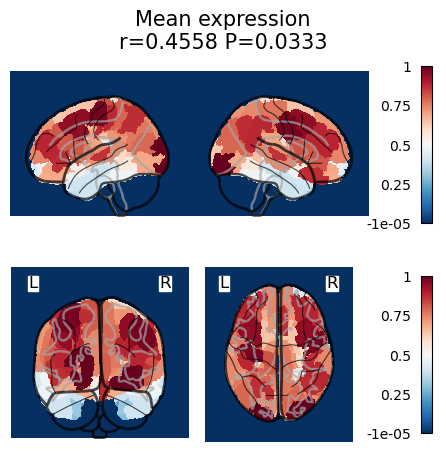

In [43]:
plt.figure(figsize=(5.5, 5))
ax1 = plt.subplot(2, 1, 1)
plotting.plot_glass_brain(top10_mean_nii, display_mode="lr", axes=ax1, cmap='RdBu_r', plot_abs=False, colorbar=True)
ax1.set_title(f"Mean expression\nr={corr_pr:.4f} P={pval:.4f}", size=15, loc="center")

ax2 = plt.subplot(2, 1, 2)
plotting.plot_glass_brain(top10_mean_nii, display_mode="yz", axes=ax2, cmap='RdBu_r', plot_abs=False)
plt.savefig(f"/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/plot/Mean_expr_brainglass_kwx.png")
plotting.show()
#plt.close()

In [45]:
top10_mean2 = pd.Series(stats.zscore(top10_mean),index=top10_mean.index)

dat = np.asanyarray(atlas.dataobj)
affine = atlas.affine

tmp_img = np.zeros_like(dat)
for i, region in zip(range(64, 128), info["alias1"][64:128].values):
    tmp_img[dat==(i+1)] = top10_mean2[region]
    tmp_img[dat==(i+1-64)] = top10_mean2[region]
    pass
top10_mean_nii = nib.Nifti1Image(tmp_img, affine=affine)

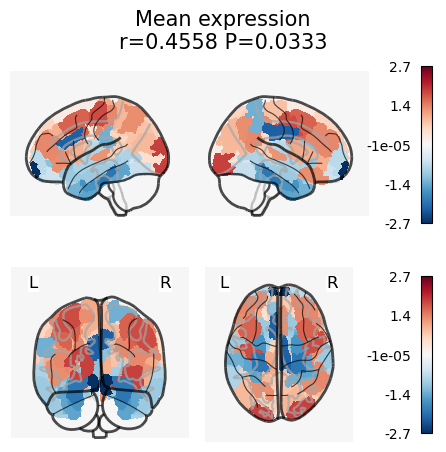

In [46]:
plt.figure(figsize=(5.5, 5))
ax1 = plt.subplot(2, 1, 1)
plotting.plot_glass_brain(top10_mean_nii, display_mode="lr", axes=ax1, cmap='RdBu_r', plot_abs=False, colorbar=True)
ax1.set_title(f"Mean expression\nr={corr_pr:.4f} P={pval:.4f}", size=15, loc="center")

ax2 = plt.subplot(2, 1, 2)
plotting.plot_glass_brain(top10_mean_nii, display_mode="yz", axes=ax2, cmap='RdBu_r', plot_abs=False)
plt.savefig(f"/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/plot/Mean_expr_brainglass.zscore_kwx.png")
plotting.show()
#plt.close()

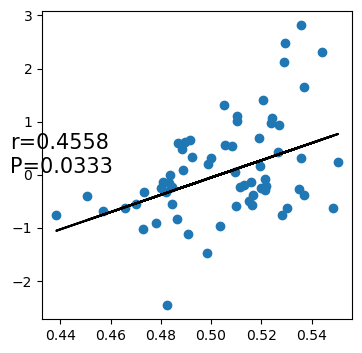

In [47]:
x1 = top10_mean.values
y1 = wm_roi_map.values.ravel()
reg = TheilSenRegressor().fit(x1.reshape(-1, 1), y1)
y2 = reg.predict(x1.reshape(-1, 1))

plt.figure(figsize=(4, 4))
plt.scatter(x1, y1)
plt.plot(x1, y2, color="black")
plt.text(x=0.42, y=0.04, s=f"r={corr_pr:.4f}\nP={pval:.4f}", size=15)
plt.savefig("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/plot/expr_map_correlation_kwx.pdf")
plt.show()